<a href="https://colab.research.google.com/github/tusharviradiya/ai-ml/blob/main/11_Practice/week3/Classification_Models_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ==============================================================================
# 1. IMPORTS & DATA LOADING
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")

# Active raw URL for the Kaggle/UCI Heart Disease dataset (1,025 rows, 14 columns)
url = "https://raw.githubusercontent.com/dileep-lingamallu/Heart-Disease-Prediction-Dataset/main/heart.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
# ==============================================================================
# 2. PREPROCESSING & TRAIN-TEST SPLIT
# ==============================================================================
# Target is 'target' (1: Heart Disease, 0: Normal)
X = df.drop(columns=["target"], errors="ignore")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,Support Vector Machine (SVC),0.926829,0.916667,0.942857,0.929577,0.977143
1,Decision Tree,0.873171,0.862385,0.895238,0.878505,0.932619
4,K-Nearest Neighbors,0.863415,0.873786,0.857143,0.865385,0.962905
0,Logistic Regression,0.809756,0.761905,0.914286,0.831169,0.929810


/tmp/ipykernel_992/3429129343.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="F1-Score", palette="viridis")


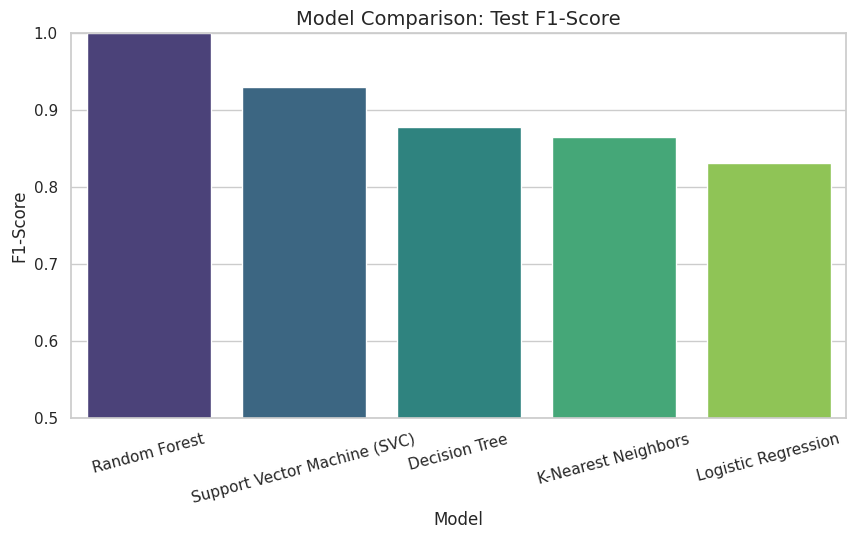

In [7]:
# ==============================================================================
# 3. MULTI-MODEL TRAINING & BENCHMARKING
# ==============================================================================
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine (SVC)": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
}

results = []

for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    y_proba = clf.predict_proba(X_test_scaled)[:, 1]

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        }
    )

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
display(results_df)

# Visual Comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="F1-Score", palette="viridis")
plt.title("Model Comparison: Test F1-Score", fontsize=14)
plt.xticks(rotation=15)
plt.ylim(0.5, 1.0)
plt.show()